In [27]:
import sys
import os
import pandas as pd
# Ensure the current workspace path is in the system path for src module discovery
import matplotlib.pyplot as plt
import seaborn as sns

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from src.data_loader import DataLoader, audible_catlog_adv, audible_catlog
from src.data_cleaner import DataCleaner, clean_data

# Loading datasets from the DATASET directory
loader = DataLoader(data_dir=r"D:/workspace/lit-cluster-recommender/DATASET")

# Use the convenience functions
adv_features_df = audible_catlog_adv(data_dir=r"D:/workspace/lit-cluster-recommender/DATASET")
base_catalog_df = audible_catlog(data_dir=r"D:/workspace/lit-cluster-recommender/DATASET")

print(f"Loaded Advanced Catalog: {len(adv_features_df)} rows")
print(f"Loaded Base Catalog: {len(base_catalog_df)} rows")

# Fix: Use inplace=True to ensure columns are actually renamed
adv_features_df.rename(columns={"Book Name": "Book_Name"}, inplace=True)
base_catalog_df.rename(columns={"Book Name": "Book_Name"}, inplace=True)


Loaded Advanced Catalog: 4464 rows
Loaded Base Catalog: 6368 rows


In [28]:
from rapidfuzz import process, fuzz
from tqdm.auto import tqdm

# Optimization: Only match books that aren't exact matches already
exact_matches = set(adv_features_df['Book_Name']).intersection(set(base_catalog_df['Book_Name']))
unmatched_books = [b for b in adv_features_df['Book_Name'].unique() if b not in exact_matches]
base_catalog_names = base_catalog_df['Book_Name'].unique()

print(f"Processing {len(unmatched_books)} unmatched books (out of {len(adv_features_df['Book_Name'].unique())})")

# Use rapidfuzz for 100x speedup
matches = {}
for book_name in tqdm(unmatched_books):
    match = process.extractOne(book_name, base_catalog_names, scorer=fuzz.WRatio)
    if match and match[1] >= 90:
        matches[book_name] = match[0]


Processing 658 unmatched books (out of 4007)


In [29]:
# Create a mapping column for merging
adv_features_df['Matched_Book_Name'] = adv_features_df['Book_Name'].map(matches).fillna(adv_features_df['Book_Name'])

# Final Merge
merged_df = pd.merge(
    adv_features_df, 
    base_catalog_df, 
    left_on="Matched_Book_Name", 
    right_on="Book_Name", 
    how='inner'
)

print(f"Merged Dataframe shape: {merged_df.shape}")
merged_df.head()

Merged Dataframe shape: (4352, 14)


In [31]:
import os

output_dir = r"D:/workspace/lit-cluster-recommender/cleandata"
os.makedirs(output_dir, exist_ok=True)  # creates folder if it doesn't exist

merged_df.to_csv(os.path.join(output_dir, "merged_auduobook.csv"), index=False)

Genre Value Counts:
Genre
General                                   2264
Personal Success                            99
Classic Literature                          47
Literary Fiction                            33
Leadership                                  29
Romance (Books)                             26
Business Sales                              21
Business Careers                            20
Business Motivation & Self-Improvement      18
Self-Esteem                                 18
Name: count, dtype: int64


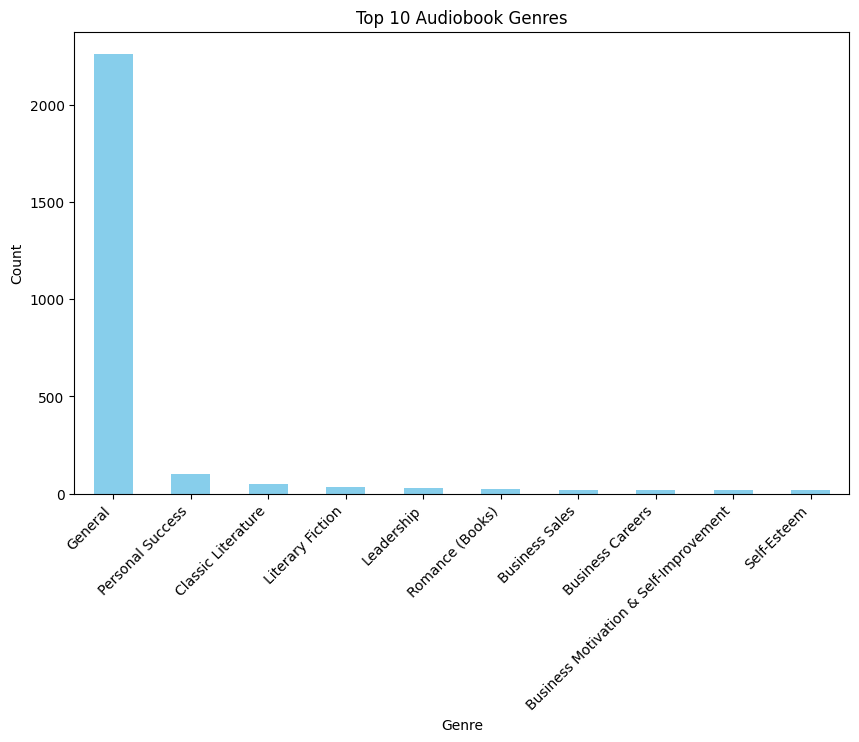

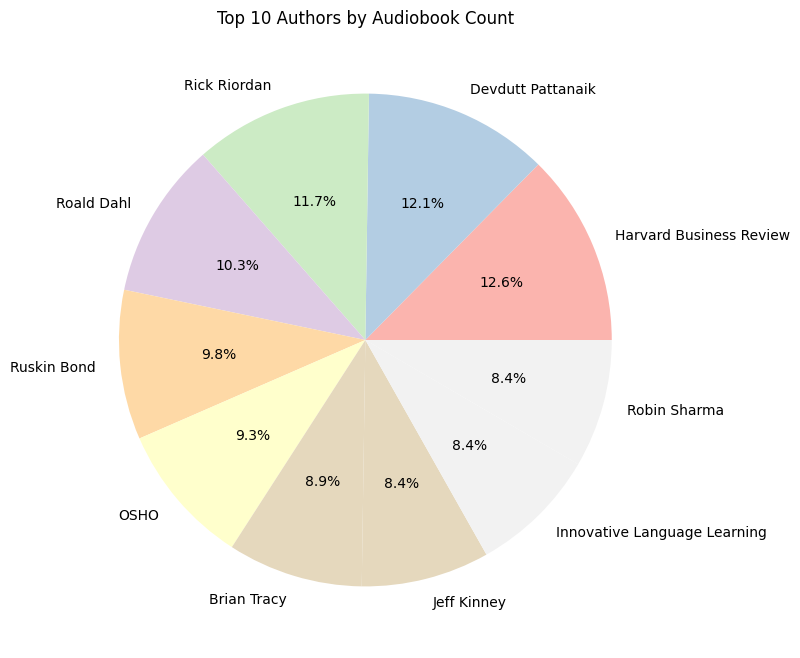

In [33]:
# 1. Extract Genre from 'Ranks and Genre' (picking the first meaningful genre after the rank)
def extract_genre(text):
    if pd.isna(text) or not isinstance(text, str):
        return 'Unknown'
    # Sample format: ",#1 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Arts & Entertainment"
    parts = [p.strip() for p in text.split(',') if p.strip()]
    for part in parts:
        if 'in ' in part and 'Audiobooks & Originals' not in part:
            return part.split('in ')[-1]
    return 'General'

merged_df['Genre'] = merged_df['Ranks and Genre'].apply(extract_genre)

# 2. Visualize Genre Distribution
print("Genre Value Counts:")
print(merged_df['Genre'].value_counts().head(10))

plt.figure(figsize=(10, 6))
merged_df['Genre'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Audiobook Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# 3. Pie Chart for Top 10 Authors (Substitute for Platform)
plt.figure(figsize=(8, 8))
merged_df['Author_x'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Top 10 Authors by Audiobook Count')
plt.ylabel('') # Hides the 'Author_x' label
plt.show()